In [1]:
!wget https://storage.yandexcloud.net/ai-2025/russian_literature.zip

--2025-08-25 14:22:43--  https://storage.yandexcloud.net/ai-2025/russian_literature.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20219459 (19M) [application/zip]
Saving to: ‘russian_literature.zip’

russian_literature. 100%[===================>]  19.28M  8.67MB/s    in 2.2s    

2025-08-25 14:22:46 (8.67 MB/s) - ‘russian_literature.zip’ saved [20219459/20219459]



In [2]:
# Разархивируем датасета во временную папку 'dataset'
!unzip -qo "russian_literature" -d ./dataset

error:  cannot create ./dataset/russian_literature/poems/Blok/╨б╤В╨╕╤Е╨╛╤В╨▓╨╛╤А╨╡╨╜╨╕╤П 1897-1903 ╨│╨│, ╨╜╨╡ ╨▓╨╛╤И╨╡╨┤╤И╨╕╨╡ ╨▓ ╨╛╤Б╨╜╨╛╨▓╨╜╨╛╨╡ ╤Б╨╛╨▒╤А╨░╨╜╨╕╨╡.txt
        File name too long
error:  cannot create ./dataset/russian_literature/publicism/Tolstoy/╨Ф╨╛╨║╨╗╨░╨┤, ╨┐╤А╨╕╨│╨╛╤В╨╛╨▓╨╗╨╡╨╜╨╜╤Л╨╕╠Ж ╨┤╨╗╤П ╨║╨╛╨╜╨│╤А╨╡╤Б╤Б╨░ ╨╛ ╨╝╨╕╤А╨╡ ╨▓ ╨б╤В╨╛╨║╨│╨╛╨╗╤М╨╝╨╡.txt
        File name too long
error:  cannot create ./dataset/russian_literature/publicism/Tolstoy/╨Я╨╛╤З╨╡╨╝╤Г ╤Е╤А╨╕╤Б╤В╨╕╨░╨╜╤Б╨║╨╕╨╡ ╨╜╨░╤А╨╛╨┤╤Л ╨▓╨╛╨╛╨▒╤Й╨╡ ╨╕ ╨▓ ╨╛╤Б╨╛╨▒╨╡╨╜╨╜╨╛╤Б╤В╨╕ ╤А╤Г╤Б╤Б╨║╨╕╨╕╠Ж ╨╜╨░╤Е╨╛╨┤╤П╤В╤Б╤П ╤В╨╡╨┐╨╡╤А╤М ╨▓ ╨▒╨╡╨┤╤Б╤В╨▓╨╡╨╜╨╜╨╛╨╝ ╨┐╨╛╨╗╨╛╨╢╨╡╨╜╨╕╨╕.txt
        File name too long
error:  cannot create ./dataset/russian_literature/prose/Gogol/╨Я╨╛╨▓╨╡╤Б╤В╤М ╨╛ ╤В╨╛╨╝, ╨║╨░╨║ ╨┐╨╛╤Б╤Б╨╛╤А╨╕╨╗╤Б╤П ╨Ш╨▓╨░╨╜ ╨Ш╨▓╨░╨╜╨╛╨▓╨╕╤З ╤Б ╨Ш╨▓╨░╨╜╨╛╨╝ ╨Э╨╕╨║╨╕╤Д╨╛╤А╨╛╨▓╨╕╤З╨╡╨╝.txt
        File name too long


In [3]:
!dir ./dataset/russian_literature/prose

Blok	 Chekhov     Gogol  Herzen     Pushkin	Turgenev
Bryusov  Dostoevsky  Gorky  Lermontov  Tolstoy


In [4]:
!dir ./dataset/russian_literature/poems

Blok  Lermontov  Nekrasov  Pushkin


In [5]:
# Загрузка необходимых библиотек
import glob # Вспомогательный модуль для работы с файловой системой
import numpy as np
from keras import utils
from keras.models import Sequential
from keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation
#from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Для работы с матрицей ошибок


# Выбираем их явно, чтобы список был перед глазами, и отложилось в голове, что имена писателей (точнее их порядковый номер) - это метки
CLASS_LIST=["Dostoevsky", "Tolstoy", "Turgenev", "Chekhov", "Gorky" ]

all_texts = {} # Собираем в словарь весь датасет

for author in CLASS_LIST:
  all_texts[author] = '' # Инициализируем пустой строкой новый ключ словаря
  for path in glob.glob('./dataset/russian_literature/prose/{}/*.txt'.format(author)) +  glob.glob('./dataset/russian_literature/poems/{}/*.txt'.format(author)): # Поиск файлов по шаблону
    with open(f'{path}', 'r', errors='ignore') as f: # игнорируем ошибки (например символы из другой кодировки)
                # Загрузка содержимого файла в строку
                text = f.read()

    all_texts[author]  += ' ' + text.replace('\n', ' ') # Заменяем символ перехода на новую строку пробелом

In [6]:
# используем генератор цикла для получения длины текстов по каждому автору
total = sum(len(i) for i in all_texts.values())
print(f'Датасет состоит из {total} символов')

Датасет состоит из 29117712 символов


In [7]:
print('Общая выборка по писателям:')
for author in CLASS_LIST:
    # удобный метод форматирования 2 знака после запятой f'{ВЫРАЖЕНИЕ:.2f}'
    print(f'{author} - {len(all_texts[author])} символов, доля в общей базе: {len(all_texts[author])/total*100 :.2f}%')

Общая выборка по писателям:
Dostoevsky - 11221679 символов, доля в общей базе: 38.54%
Tolstoy - 9392435 символов, доля в общей базе: 32.26%
Turgenev - 2345243 символов, доля в общей базе: 8.05%
Chekhov - 1834330 символов, доля в общей базе: 6.30%
Gorky - 4324025 символов, доля в общей базе: 14.85%


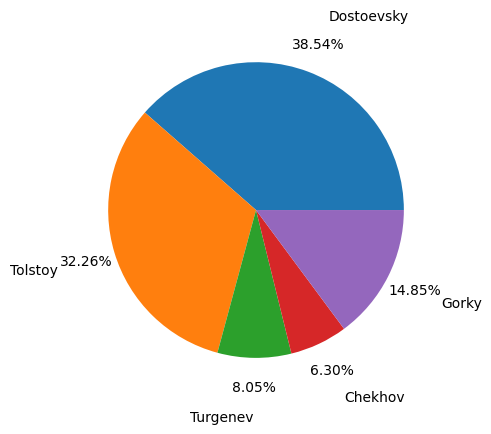

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline
fig, ax = plt.subplots()
ax.pie([len(i) for i in all_texts.values()], # формируем список значений как длина символов текста каждого автора
       labels=CLASS_LIST,                    # список меток
       pctdistance=1.2,                      # дистанция размещения % (1 - граница окружности)
       labeldistance=1.4,                    # размещение меток (1 - граница окружности)
       autopct='%1.2f%%'                     # формат для % (2 знака после запятой)
      )
plt.show()

### Токенизация

In [9]:
pip install razdel

In [10]:
from razdel import tokenize

In [11]:
from razdel import tokenize
from collections import Counter

def create_vocabulary(texts, num_words=10000, lower=True, oov_token='неизвестное_слово'):
    """Создание словаря из текстов"""
    all_tokens = []

    for text in texts:
        tokens = [token.text for token in tokenize(text)]
        if lower:
            tokens = [token.lower() for token in tokens]
        all_tokens.extend(tokens)

    # Создаем словарь
    word_counts = Counter(all_tokens)
    vocabulary = {}

    # Добавляем OOV токен
    if oov_token:
        vocabulary[oov_token] = 1

    # Добавляем самые частые слова
    for idx, (word, count) in enumerate(word_counts.most_common(num_words - 1), start=2 if oov_token else 1):
        vocabulary[word] = idx

    return vocabulary

def text_to_sequence(text, vocabulary, lower=True, oov_token='неизвестное_слово'):
    """Преобразование текста в последовательность индексов"""
    tokens = [token.text for token in tokenize(text)]
    if lower:
        tokens = [token.lower() for token in tokens]

    sequence = []
    for token in tokens:
        if token in vocabulary:
            sequence.append(vocabulary[token])
        elif oov_token in vocabulary:
            sequence.append(vocabulary[oov_token])

    return sequence

# Использование
NUM_WORDS = 10000

# Создаем словарь
vocabulary = create_vocabulary(
    all_texts.values(),
    num_words=NUM_WORDS,
    lower=True,
    oov_token='неизвестное_слово'
)

# Преобразование всех текстов в последовательности
sequences = []
for text in all_texts.values():
    sequence = text_to_sequence(text, vocabulary)
    sequences.append(sequence)

# Получение статистики
print(f"Размер словаря: {len(vocabulary)}")
print(f"Пример словаря: {list(vocabulary.items())[:10]}")

Размер словаря: 10000
Пример словаря: [('неизвестное_слово', 1), (',', 2), ('.', 3), ('и', 4), ('в', 5), ('не', 6), ('что', 7), ('–', 8), ('я', 9), ('на', 10)]


In [12]:
# Проверка индекса слова в словаре
try:
    print('Вы ввели слово с индексом:', tokenizer.word_index[input('Введите слово (в нижнем регистре): ')])
except:
    print('Такого слова нет в словаре')

Такого слова нет в словаре


In [13]:
author = "Gorky"
cls = CLASS_LIST.index(author)

print("Фрагмент обучающего текста:")
print("В виде оригинального текста:              ", all_texts[author][:120])
print("Он же в виде последовательности индексов: ", sequences[cls][:20])

Фрагмент обучающего текста:
В виде оригинального текста:                Максим Горький МАКАР ЧУДРА С моря дул влажный, холодный ветер, разнося по степи задумчивую мелодию плеска набегавшей на
Он же в виде последовательности индексов:  [2883, 5385, 2326, 1, 13, 3125, 1, 1, 2, 2769, 1163, 2, 1, 40, 5166, 1, 1, 1, 1, 10]


In [14]:
# используем генератор цикла для получения длины текстов по каждому автору
total = sum(len(i) for i in sequences)
print(f'Датасет состоит из {total} слов')

Датасет состоит из 5856792 слов


In [15]:
print('Общая выборка по писателям (по словам):')
mean_list = np.array([])
for author in CLASS_LIST:
    cls = CLASS_LIST.index(author)
    print(f'{author} - {len(sequences[cls])} слов, доля в общей базе: {len(sequences[cls])/total*100 :.2f}%')
    mean_list = np.append(mean_list, len(sequences[cls]))

print('Среднее значение слов: ', np.round(mean_list.mean()))
print('Медианное значение слов: ', np.median(mean_list))

Общая выборка по писателям (по словам):
Dostoevsky - 2256313 слов, доля в общей базе: 38.52%
Tolstoy - 1860486 слов, доля в общей базе: 31.77%
Turgenev - 474895 слов, доля в общей базе: 8.11%
Chekhov - 376425 слов, доля в общей базе: 6.43%
Gorky - 888673 слов, доля в общей базе: 15.17%
Среднее значение слов:  1171358.0
Медианное значение слов:  888673.0


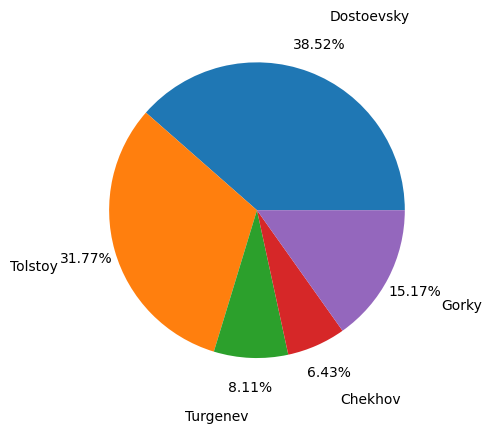

In [16]:
fig, ax = plt.subplots()
ax.pie([len(i) for i in sequences], # формируем список значений как длина символов текста каждого автора
       labels=CLASS_LIST,                    # список меток
       pctdistance=1.2,                      # дистанция размещения % (1 - граница окружности)
       labeldistance=1.4,                    # размещение меток (1 - граница окружности)
       autopct='%1.2f%%'                     # формат для % (2 знака после запятой)
      )
plt.show()

### Балансировка датасета

In [17]:
# Находим минимальный размер класса
class_sizes = [len(seq) for seq in sequences]
min_size = min(class_sizes)
print(f"Минимальный размер класса: {min_size}")

# Балансируем все классы до минимального размера
CLASS_LIST_BALANCE = []
seq_train_balance = []

for author, seq in zip(CLASS_LIST, sequences):
    # Для каждого автора берем min_size последовательностей
    if len(seq) >= min_size:
        seq_train_balance.append(seq[:min_size])
        CLASS_LIST_BALANCE.append(author)
    else:
        # Если класс меньше минимального, пропускаем (но такого не должно быть)
        print(f"Пропускаем {author} - слишком мало данных")
        continue

Минимальный размер класса: 376425


In [18]:
total = sum(len(i) for i in seq_train_balance)

print('Сбалансированная выборка по писателям:')
mean_list_balance = np.array([])
for author in CLASS_LIST_BALANCE:
    cls = CLASS_LIST_BALANCE.index(author)
    print(f'{author} - {len(seq_train_balance[cls])} последовательностей, доля: {len(seq_train_balance[cls])/total*100:.2f}%')
    mean_list_balance = np.append(mean_list_balance, len(seq_train_balance[cls]))

print('Среднее значение: ', np.round(mean_list_balance.mean()))
print('Медианное значение: ', np.median(mean_list_balance))

Сбалансированная выборка по писателям:
Dostoevsky - 376425 последовательностей, доля: 20.00%
Tolstoy - 376425 последовательностей, доля: 20.00%
Turgenev - 376425 последовательностей, доля: 20.00%
Chekhov - 376425 последовательностей, доля: 20.00%
Gorky - 376425 последовательностей, доля: 20.00%
Среднее значение:  376425.0
Медианное значение:  376425.0


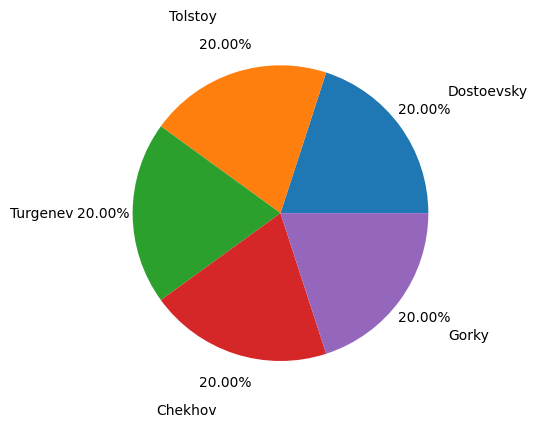

In [19]:
fig, ax = plt.subplots()
ax.pie([len(i) for i in seq_train_balance],  # формируем список значений как длина символов текста каждого автора
       labels=CLASS_LIST_BALANCE,            # список меток
       pctdistance=1.2,                      # дистанция размещения % (1 - граница окружности)
       labeldistance=1.4,                    # размещение меток (1 - граница окружности)
       autopct='%1.2f%%'                     # формат для % (2 знака после запятой)
      )
plt.show()

### Создание обучающей и проверочной выборок методом скользящего окна

In [20]:
import numpy as np
from sklearn.model_selection import train_test_split

WIN_SIZE = 1000   # Ширина окна в токенах
WIN_STEP = 100    # Шаг окна в токенах

def seq_split(sequence, win_size, step):
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, step)]

def seq_vectorize(
    seq_list,      # Последовательность
    test_split,    # Доля на тестовую выборку
    val_split,     # Доля на контрольную выборку
    class_list,    # Список классов
    win_size,      # Ширина скользящего окна
    step           # Шаг скользящего окна
):

    # Списки для результирующих данных
    x_train, y_train, x_test, y_test, x_val, y_val = [], [], [], [], [], []

    # Пробежимся по всем классам:
    for class_item in class_list:
        cls = class_list.index(class_item)

        # Первое разбиение: отделяем тестовую выборку
        gate_test = int(len(seq_list[cls]) * (1 - test_split))

        # Оставшиеся данные делим на обучающую и контрольную выборки
        train_val_data = seq_list[cls][:gate_test]
        test_data = seq_list[cls][gate_test:]

        # Второе разбиение: отделяем контрольную выборку от обучающей
        gate_val = int(len(train_val_data) * (1 - val_split / (1 - test_split)))

        train_data = train_val_data[:gate_val]
        val_data = train_val_data[gate_val:]

        # Разбиваем на отрезки
        vectors_train = seq_split(train_data, win_size, step)
        vectors_val = seq_split(val_data, win_size, step)
        vectors_test = seq_split(test_data, win_size, step)

        # Добавляем отрезки в соответствующие выборки
        x_train += vectors_train
        x_val += vectors_val
        x_test += vectors_test

        # Создаем метки
        y_train += [utils.to_categorical(cls, len(class_list))] * len(vectors_train)
        y_val += [utils.to_categorical(cls, len(class_list))] * len(vectors_val)
        y_test += [utils.to_categorical(cls, len(class_list))] * len(vectors_test)

    # Возвращаем все три выборки
    return (np.array(x_train), np.array(y_train),
            np.array(x_val), np.array(y_val),
            np.array(x_test), np.array(y_test))

# Использование с 10% тестовой и 10% контрольной выборкой
x_train, y_train, x_val, y_val, x_test, y_test = seq_vectorize(
    seq_train_balance,
    test_split=0.1,
    val_split=0.1,
    class_list=CLASS_LIST_BALANCE,
    win_size=WIN_SIZE,
    step=WIN_STEP
)

print(f"Размеры выборок:")
print(f"Обучающая: {len(x_train)} примеров")
print(f"Контрольная: {len(x_val)} примеров")
print(f"Тестовая: {len(x_test)} примеров")

Размеры выборок:
Обучающая: 15010 примеров
Контрольная: 1835 примеров
Тестовая: 1835 примеров


### Вспомогательные функции

In [21]:
# Вывод графиков точности и ошибки
def show_plot(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle('График процесса обучения модели')
    ax1.plot(history.history['accuracy'],
               label='График точности на обучающей выборке')
    ax1.plot(history.history['val_accuracy'],
               label='График точности на проверочной выборке')
    ax1.xaxis.get_major_locator().set_params(integer=True) # На оси х показываем целые числа
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('График точности')
    ax1.legend()

    ax2.plot(history.history['loss'],
               label='Ошибка на обучающей выборке')
    ax2.plot(history.history['val_loss'],
               label='Ошибка на проверочной выборке')
    ax2.xaxis.get_major_locator().set_params(integer=True) # На оси х показываем целые числа
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()

# Функция вывода предсказанных значений
def show_confusion_matrix(y_true, y_pred, class_labels):
    # Матрица ошибок
    cm = confusion_matrix(np.argmax(y_true, axis=1),
                          np.argmax(y_pred, axis=1),
                          normalize='true')
    # Округление значений матрицы ошибок
    cm = np.around(cm, 3)

    # Отрисовка матрицы ошибок
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title(f'Матрица ошибок', fontsize=18)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()  # Убираем ненужную цветовую шкалу
    plt.xlabel('Предсказанные классы', fontsize=16)
    plt.ylabel('Верные классы', fontsize=16)
    fig.autofmt_xdate(rotation=45)          # Наклон меток горизонтальной оси
    plt.show()


    # Средняя точность распознавания определяется как среднее диагональных элементов матрицы ошибок
    print('\nСредняя точность распознавания: {:3.0f}%'.format(100. * cm.diagonal().mean()))


#### Модель для Bag of Words

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, BatchNormalization, GlobalMaxPooling1D

# Модель для обработки последовательностей
model_seq = Sequential([
    # Слой Embedding для преобразования индексов в плотные векторы
    Embedding(input_dim=NUM_WORDS, output_dim=128, input_length=1000),

    # LSTM слой для обработки последовательностей
    LSTM(64, return_sequences=False),
    Dropout(0.25),
    BatchNormalization(),

    # Полносвязные слои
    Dense(200, activation="relu"),
    Dropout(0.25),
    BatchNormalization(),

    # Выходной слой
    Dense(len(CLASS_LIST_BALANCE), activation='softmax')
])

model_seq.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_seq.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:

x_train_list = x_train.tolist()
x_test_list = x_test.tolist()
x_val_list = x_val.tolist()

print(f'Обучающая выборка в виде матрицы Bag of Words: {len(x_train_list)}')
print(f'Проверочная выборка в виде матрицы Bag of Words: {len(x_test_list)}')
print(f'Контрольная выборка в виде матрицы Bag of Words: {len(x_val_list)}')

Обучающая выборка в виде матрицы Bag of Words: 15010
Проверочная выборка в виде матрицы Bag of Words: 1835
Контрольная выборка в виде матрицы Bag of Words: 1835


In [30]:
x_train_array = np.array(x_train_list)
x_val_array = np.array(x_val_list)
x_test_array = np.array(x_test_list)
y_train_array = np.array(y_train)
y_val_array = np.array(y_val)
y_test_array = np.array(y_test)


from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Создаем callback для сохранения лучшей модели
checkpoint_callback = ModelCheckpoint(
    filepath='best_model.h5',          # Путь для сохранения
    monitor='val_accuracy',            # Метрика для отслеживания
    save_best_only=True,               # Сохранять только лучшую модель
    mode='max',                        # Режим: maximize accuracy
    verbose=1                          # Вывод информации
)

# Дополнительно: Early Stopping чтобы избежать переобучения
early_stopping = EarlyStopping(
    monitor='val_loss',                # Отслеживаем потерю на валидации
    patience=5,                        # Количество эпох без улучшения
    restore_best_weights=True,         # Восстанавливаем лучшие веса
    verbose=1
)

# Обучение модели с callbacks
history = model_seq.fit(
    x_train_array,
    y_train_array,
    epochs=15,
    batch_size=128,
    validation_data=(x_val_array, y_val_array),  # Используем контрольную выборку
    callbacks=[checkpoint_callback, early_stopping],  # Добавляем callbacks
    verbose=1
)

Epoch 1/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3316 - loss: 1.6958
Epoch 1: val_accuracy improved from -inf to 0.20054, saving model to best_model.h5


118/118 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.3325 - loss: 1.6929 - val_accuracy: 0.2005 - val_loss: 1.5413
Epoch 2/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8258 - loss: 0.4584
Epoch 2: val_accuracy improved from 0.20054 to 0.38801, saving model to best_model.h5


118/118 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.8262 - loss: 0.4576 - val_accuracy: 0.3880 - val_loss: 1.3218
Epoch 3/15
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9315 - loss: 0.1982
Epoch 3: val_accuracy improved from 0.38801 to 0.39346, saving model to best_model.h5


118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.9314 - loss: 0.1985 - val_accuracy: 0.3935 - val_loss: 2.9538
Epoch 4/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8308 - loss: 0.4612
Epoch 4: val_accuracy improved from 0.39346 to 0.75313, saving model to best_model.h5


118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.8313 - loss: 0.4600 - val_accuracy: 0.7531 - val_loss: 0.6242
Epoch 5/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9712 - loss: 0.0886
Epoch 5: val_accuracy did not improve from 0.75313
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.9713 - loss: 0.0884 - val_accuracy: 0.7275 - val_loss: 1.1762
Epoch 6/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9812 - loss: 0.0625
Epoch 6: val_accuracy did not improve from 0.75313
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9812 - loss: 0.0624 - val_accuracy: 0.6807 - val_loss: 1.4693
Epoch 7/15
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9718 - loss: 0.0864
Epoch 7: val_accuracy improved from 0.75313 to 0.95204, saving model to best_model.h5


118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9720 - loss: 0.0859 - val_accuracy: 0.9520 - val_loss: 0.1665
Epoch 8/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9794 - loss: 0.0701
Epoch 8: val_accuracy did not improve from 0.95204
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9794 - loss: 0.0699 - val_accuracy: 0.6687 - val_loss: 1.4152
Epoch 9/15
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9847 - loss: 0.0474
Epoch 9: val_accuracy did not improve from 0.95204
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.9848 - loss: 0.0471 - val_accuracy: 0.9499 - val_loss: 0.2581
Epoch 10/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9989 - loss: 0.0087
Epoch 10: val_accuracy improved from 0.95204 to 0.98965, saving model to best_model.h5


118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.9989 - loss: 0.0087 - val_accuracy: 0.9896 - val_loss: 0.0619
Epoch 11/15
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 6.9288e-04
Epoch 11: val_accuracy improved from 0.98965 to 0.99074, saving model to best_model.h5


118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 1.0000 - loss: 6.9189e-04 - val_accuracy: 0.9907 - val_loss: 0.0543
Epoch 12/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9789 - loss: 0.0693
Epoch 12: val_accuracy did not improve from 0.99074
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.9787 - loss: 0.0698 - val_accuracy: 0.6322 - val_loss: 2.7098
Epoch 13/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9760 - loss: 0.0809
Epoch 13: val_accuracy did not improve from 0.99074
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.9761 - loss: 0.0806 - val_accuracy: 0.9035 - val_loss: 0.4456
Epoch 14/15
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9946 - loss: 0.0182
Epoch 14: val_accuracy did not improve from 0.99074
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9945 - loss: 0.0186 - val_accuracy: 0.2812 - val_loss: 3.4900
Epoch 15/15
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9195 - loss: 0.2478
Epoch 15: val

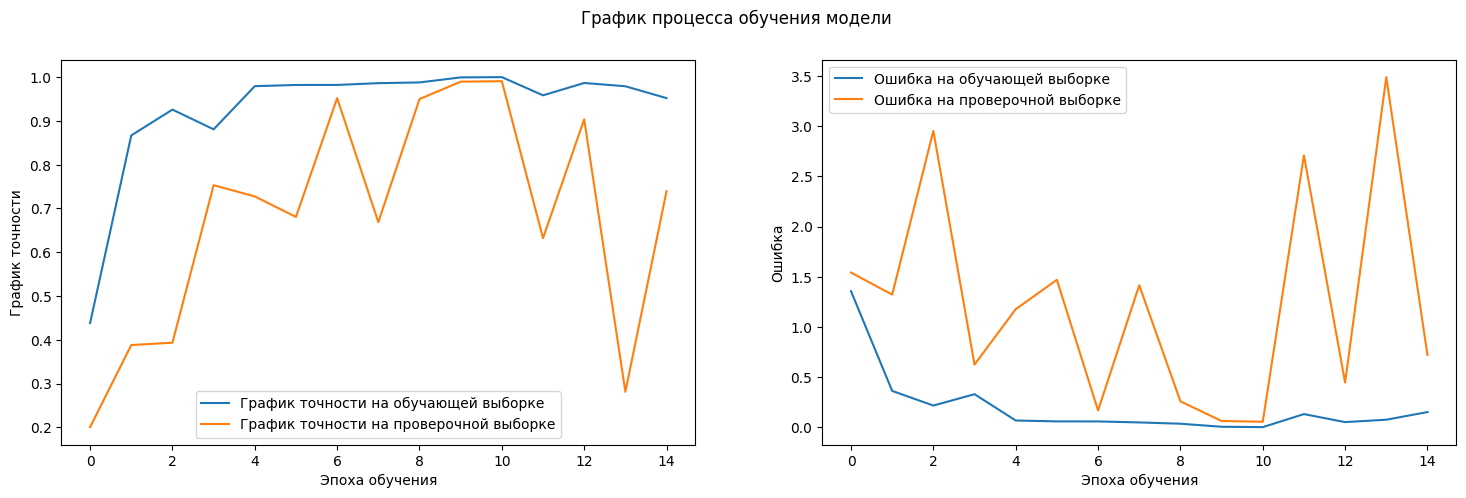

In [31]:
show_plot(history)

In [33]:
# Оценка модели на контрольной выборке
val_loss, val_accuracy = model_seq.evaluate(
    x_test_array,
    y_test_array,
)

print(f"Потери на контрольной выборке: {val_loss:.4f}")
print(f"Точность на контрольной выборке: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9782 - loss: 0.1195
Потери на контрольной выборке: 0.2772
Точность на контрольной выборке: 0.9531 (95.31%)
